# EDA & Feature Engineering — Dislog PFE

**Objective**: Connect to the SQL Server data warehouse, explore all star tables, build RFM features, perform customer behavior analysis, and produce statistical summaries and visualizations (Phase 2).

---

## Table of Contents

1. [Setup & DB Connection](#1)
2. [Exploratory Data Analysis on All Tables](#2)
3. [Build RFM Features](#3)
4. [Customer Behavior Analysis](#4)
5. [Statistical Summaries and Distributions](#5)
6. [Visualizations](#6)
7. [Conclusion & Next Steps](#7)

<a id='1'></a>
## 1. Setup & DB Connection

Add project root to path, load environment variables, connect to SQL Server, and load all 8 star tables.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

# Project root (parent of notebooks/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
load_dotenv(PROJECT_ROOT / '.env')

from src.config import get_sqlserver_connection_string

# Plot style (match 01_data_profiling)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

engine = create_engine(get_sqlserver_connection_string())
print('Database connection OK.')

Database connection OK.


In [2]:
# Load all 8 star schema tables.
# Use sample for fact tables to avoid MemoryError on machines with limited RAM (~9M + 1.4M rows).(not recommended)
# Set USE_FULL_FACTS = True only if you have 8GB+ free RAM for the notebook.
USE_FULL_FACTS = True  # Set to False if you get MemoryError (e.g. low free RAM)
FACT_SALES_LIMIT = 500_000   # rows (used when USE_FULL_FACTS is False)
FACT_INVOICES_LIMIT = 200_000

df_dim_date = pd.read_sql('SELECT * FROM DimDate', engine)
df_dim_customer = pd.read_sql('SELECT * FROM DimCustomer', engine)
df_dim_seller = pd.read_sql('SELECT * FROM DimSeller', engine)
df_dim_product = pd.read_sql('SELECT * FROM DimProduct', engine)
df_dim_promotion = pd.read_sql('SELECT * FROM DimPromotion', engine)
df_dim_payment = pd.read_sql('SELECT * FROM DimPaymentMethod', engine)
if USE_FULL_FACTS:
    df_fact_sales = pd.read_sql('SELECT * FROM FactSales', engine)
    df_fact_invoices = pd.read_sql('SELECT * FROM FactInvoices', engine)
else:
    df_fact_sales = pd.read_sql(f'SELECT TOP ({FACT_SALES_LIMIT}) * FROM FactSales', engine)
    df_fact_invoices = pd.read_sql(f'SELECT TOP ({FACT_INVOICES_LIMIT}) * FROM FactInvoices', engine)
    print(f'(Using sample: FactSales TOP {FACT_SALES_LIMIT:,}, FactInvoices TOP {FACT_INVOICES_LIMIT:,}. Set USE_FULL_FACTS=True for full data.)')

tables_info = [
    ('DimDate', df_dim_date), ('DimCustomer', df_dim_customer), ('DimSeller', df_dim_seller),
    ('DimProduct', df_dim_product), ('DimPromotion', df_dim_promotion), ('DimPaymentMethod', df_dim_payment),
    ('FactSales', df_fact_sales), ('FactInvoices', df_fact_invoices)
]
print('Tables loaded:')
for name, df in tables_info:
    print(f'  {name}: {len(df):,} rows')

Tables loaded:
  DimDate: 388 rows
  DimCustomer: 87,653 rows
  DimSeller: 410 rows
  DimProduct: 2,320 rows
  DimPromotion: 4 rows
  DimPaymentMethod: 3 rows
  FactSales: 9,229,070 rows
  FactInvoices: 1,437,421 rows


<a id='2'></a>
## 2. Exploratory Data Analysis on All Tables

For each dimension and fact table: shape, dtypes, sample, describe, null counts, and distinct key counts. Then check date ranges and FK sanity.

In [4]:
from IPython.display import display, HTML
import pandas as pd
import numpy as np


# ─────────────────────────────────────────────────────────────────────────────
#  Shared helpers
# ─────────────────────────────────────────────────────────────────────────────
_BLUE   = "#2E75B6"
_STRIPE = "#f2f7fc"

def _styled_table(df_input):
    """DataFrame → styled HTML table with alternating rows and index column."""
    rows = "<thead><tr style=\'background:#2E75B6; color:white;\'>"
    rows += "<th style=\'padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\'>#</th>"
    for col in df_input.columns:
        rows += f"<th style=\'padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\'>{col}</th>"
    rows += "</tr></thead><tbody>"
    for i, (_, row) in enumerate(df_input.iterrows()):
        bg = "white" if i % 2 == 0 else _STRIPE
        rows += f"<tr style=\'background:{bg};\'>"
        rows += f"<td style=\'padding:6px 14px; font-size:13px; color:#888; border-bottom:1px solid #dde4ed;\'>{i}</td>"
        for val in row:
            rows += f"<td style=\'padding:6px 14px; font-size:13px; color:#1a1a1a; border-bottom:1px solid #dde4ed;\'>{val}</td>"
        rows += "</tr>"
    rows += "</tbody>"
    return f"<table style=\'border-collapse:collapse; width:100%; margin-bottom:20px;\'>{rows}</table>"

def _section_label(text):
    return (
        f"<div style=\"font-family:Calibri,\'Segoe UI\',sans-serif; "
        f"font-size:11px; font-weight:700; color:{_BLUE}; "
        f"letter-spacing:0.7px; text-transform:uppercase; margin-bottom:7px;\">"
        f"{text}</div>"
    )

def _title_banner(name, nrows, ncols):
    return (
        f"<div style=\"background:{_BLUE}; padding:10px 16px; margin-bottom:18px;\">"
        f"<div style=\"font-family:Calibri,\'Segoe UI\',sans-serif; font-size:17px; font-weight:700; color:#ffffff;\">{name}</div>"
        f"<div style=\"font-family:Calibri,\'Segoe UI\',sans-serif; font-size:12px; color:#cce3f5; margin-top:3px;\">"
        f"{nrows:,} rows &nbsp;·&nbsp; {ncols} columns</div></div>"
    )

def _col_overview(df, nulls, null_pct):
    html = _section_label("Column Overview")
    html += (
        f"<table style=\"border-collapse:collapse; width:100%; margin-bottom:20px;\">"
        f"<thead><tr style=\"background:{_BLUE}; color:white;\">"
        f"<th style=\"padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\">Column</th>"
        f"<th style=\"padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\">Type</th>"
        f"<th style=\"padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\">Nulls</th>"
        f"<th style=\"padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\">Null %</th>"
        f"</tr></thead><tbody>"
    )
    for i, col in enumerate(df.columns):
        bg = "white" if i % 2 == 0 else _STRIPE
        nc = "#C00000" if nulls[col] > 0 else "#375623"
        html += (
            f"<tr style=\"background:{bg};\">"
            f"<td style=\"padding:6px 14px; font-size:13px; color:#1a1a1a; border-bottom:1px solid #dde4ed;\">{col}</td>"
            f"<td style=\"padding:6px 14px; font-size:13px; color:#555;    border-bottom:1px solid #dde4ed;\">{df[col].dtype}</td>"
            f"<td style=\"padding:6px 14px; font-size:13px; color:{nc}; border-bottom:1px solid #dde4ed;\">{nulls[col]:,}</td>"
            f"<td style=\"padding:6px 14px; font-size:13px; color:{nc}; border-bottom:1px solid #dde4ed;\">{null_pct[col]}%</td>"
            f"</tr>"
        )
    html += "</tbody></table>"
    return html


# ─────────────────────────────────────────────────────────────────────────────
#  profile_dataframe  — for Dim* tables
# ─────────────────────────────────────────────────────────────────────────────
def profile_dataframe(name, df):
    nulls    = df.isnull().sum()
    null_pct = (nulls / len(df) * 100).round(1)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    html = f"<div style=\"font-family:Calibri,\'Segoe UI\',sans-serif; margin:32px 0 24px 0; max-width:1100px;\">"
    html += _title_banner(name, df.shape[0], df.shape[1])
    html += _col_overview(df, nulls, null_pct)
    html += _section_label("Sample Rows (first 5)")
    html += _styled_table(df.head())
    if num_cols:
        html += _section_label("Numeric Summary")
        html += _styled_table(df[num_cols].describe().round(2).reset_index().rename(columns={"index": "stat"}))
    html += "</div><hr style=\'border:none; border-top:1px solid #dde4ed; margin:4px 0 0 0;\'>"
    display(HTML(html))


# ─────────────────────────────────────────────────────────────────────────────
#  profile_fact_table  — for Fact* tables
# ─────────────────────────────────────────────────────────────────────────────
def profile_fact_table(name, df, distinct_checks: dict):
    """
    distinct_checks: {col: label}  e.g. {'SaleID': 'Distinct SaleID'}
    Adds a Key Metrics card row above Column Overview.
    """
    nulls    = df.isnull().sum()
    null_pct = (nulls / len(df) * 100).round(1)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    html = f"<div style=\"font-family:Calibri,\'Segoe UI\',sans-serif; margin:32px 0 24px 0; max-width:1100px;\">"
    html += _title_banner(name, df.shape[0], df.shape[1])

    # Key Metrics cards
    if distinct_checks:
        html += _section_label("Key Metrics")
        html += "<div style=\"display:flex; gap:16px; margin-bottom:20px; flex-wrap:wrap;\">"
        for col, label in distinct_checks.items():
            count = df[col].nunique()
            html += (
                f"<div style=\"background:{_STRIPE}; border:1px solid #dde4ed; border-top:3px solid {_BLUE}; "
                f"padding:12px 20px; min-width:160px;\">"
                f"<div style=\"font-size:11px; color:#888; text-transform:uppercase; letter-spacing:0.5px; margin-bottom:4px;\">{label}</div>"
                f"<div style=\"font-size:22px; font-weight:700; color:#1a1a1a;\">{count:,}</div>"
                f"</div>"
            )
        html += "</div>"

    html += _col_overview(df, nulls, null_pct)
    html += _section_label("Sample Rows (first 5)")
    html += _styled_table(df.head())
    if num_cols:
        html += _section_label("Numeric Summary")
        html += _styled_table(df[num_cols].describe().round(2).reset_index().rename(columns={"index": "stat"}))
    html += "</div><hr style=\'border:none; border-top:1px solid #dde4ed; margin:4px 0 0 0;\'>"
    display(HTML(html))


# ── Dim tables ────────────────────────────────────────────────────────────────
for _name, _df in [
    ('DimDate',          df_dim_date),
    ('DimCustomer',      df_dim_customer),
    ('DimSeller',        df_dim_seller),
    ('DimProduct',       df_dim_product),
    ('DimPromotion',     df_dim_promotion),
    ('DimPaymentMethod', df_dim_payment),
]:
    profile_dataframe(_name, _df)


Column,Type,Nulls,Null %
DateKey,int64,0,0.0%
FullDate,object,0,0.0%
Year,int64,0,0.0%
Quarter,int64,0,0.0%
Month,int64,0,0.0%
Day,int64,0,0.0%
DayOfWeek,int64,0,0.0%
DayName,str,0,0.0%
MonthName,str,0,0.0%
IsWeekend,bool,0,0.0%


Column,Type,Nulls,Null %
CustomerKey,int64,0,0.0%
AccountID,str,0,0.0%
AccountName,str,"10,341",11.8%
RegionID,str,192,0.2%
RegionDescription,str,467,0.5%
SectorID,str,317,0.4%
SectorDescription,str,322,0.4%
ValidFrom,object,0,0.0%
ValidTo,object,"87,653",100.0%
IsCurrent,bool,0,0.0%


In [5]:
# ── Fact tables ───────────────────────────────────────────────────────────────
profile_fact_table(
    'FactSales', df_fact_sales,
    distinct_checks={
        'SaleID':      'Distinct SaleID',
        'CustomerKey': 'Distinct CustomerKey',
        'SellerKey':   'Distinct SellerKey',
        'ProductKey':  'Distinct ProductKey',
    }
)

profile_fact_table(
    'FactInvoices', df_fact_invoices,
    distinct_checks={
        'InvoiceID':   'Distinct InvoiceID',
        'CustomerKey': 'Distinct CustomerKey',
        'SaleID':      'Distinct SaleID',
    }
)


Column,Type,Nulls,Null %
SalesKey,int64,0,0.0%
SaleID,int64,0,0.0%
OrderDateKey,int64,0,0.0%
DeliveryDateKey,int64,0,0.0%
CustomerKey,int64,0,0.0%
SellerKey,int64,0,0.0%
ProductKey,int64,0,0.0%
PromotionKey,int64,0,0.0%
Quantity,int64,0,0.0%
UnitPrice,float64,0,0.0%


In [6]:
# Date range and FK sanity
# OrderDateKey / PaymentDateKey are YYYYMMDD integers
order_keys = df_fact_sales['OrderDateKey'].dropna()
pay_keys = df_fact_invoices['PaymentDateKey'].dropna()
print('OrderDateKey range:', order_keys.min(), '-', order_keys.max())
print('PaymentDateKey range:', pay_keys.min(), '-', pay_keys.max())

# Sanity: FactSales.CustomerKey in DimCustomer?
cust_keys = set(df_dim_customer['CustomerKey'])
fs_cust = set(df_fact_sales['CustomerKey'].dropna().astype(int))
fi_cust = set(df_fact_invoices['CustomerKey'].dropna().astype(int))
print('FactSales CustomerKeys all in DimCustomer:', fs_cust.issubset(cust_keys))
print('FactInvoices CustomerKeys all in DimCustomer:', fi_cust.issubset(cust_keys))

OrderDateKey range: 20240101 - 20241231
PaymentDateKey range: 20240101 - 20241231
FactSales CustomerKeys all in DimCustomer: True
FactInvoices CustomerKeys all in DimCustomer: True


<a id='3'></a>
## 3. Build RFM Features

One row per customer (CustomerKey). **R**ecency = days since last order, **F**requency = number of distinct orders, **M**onetary = total amount spent. Reference date = max order date in the data.

In [7]:
# Reference date: latest order date in FactSales (DateKey is YYYYMMDD)
max_date_key = int(df_fact_sales['OrderDateKey'].max())
ref_date = pd.to_datetime(str(max_date_key), format='%Y%m%d').date()

# Customer-level aggregates from FactSales
agg_sales = df_fact_sales.groupby('CustomerKey').agg(
    last_order_date_key=('OrderDateKey', 'max'),
    order_count=('SaleID', 'nunique'),
    total_amount=('LineTotalAmount', 'sum')
).reset_index()

# Convert last OrderDateKey to date and compute Recency (days since last order)
agg_sales['last_order_date'] = pd.to_datetime(agg_sales['last_order_date_key'].astype(str), format='%Y%m%d').dt.date
agg_sales['Recency']   = (ref_date - agg_sales['last_order_date']).apply(lambda x: x.days)
agg_sales['Frequency'] = agg_sales['order_count']
agg_sales['Monetary']  = agg_sales['total_amount']

df_rfm = agg_sales[['CustomerKey', 'Recency', 'Frequency', 'Monetary']].copy()

profile_fact_table(
    f'RFM Base Table  (ref date: {ref_date})', df_rfm,
    distinct_checks={'CustomerKey': 'Distinct Customers'}
)


<a id='4'></a>
## 4. Customer Behavior Analysis

Distributions of R, F, M; simple RFM segments (quartiles); top customers by frequency and monetary; breakdowns by Region, Sector, and top products.

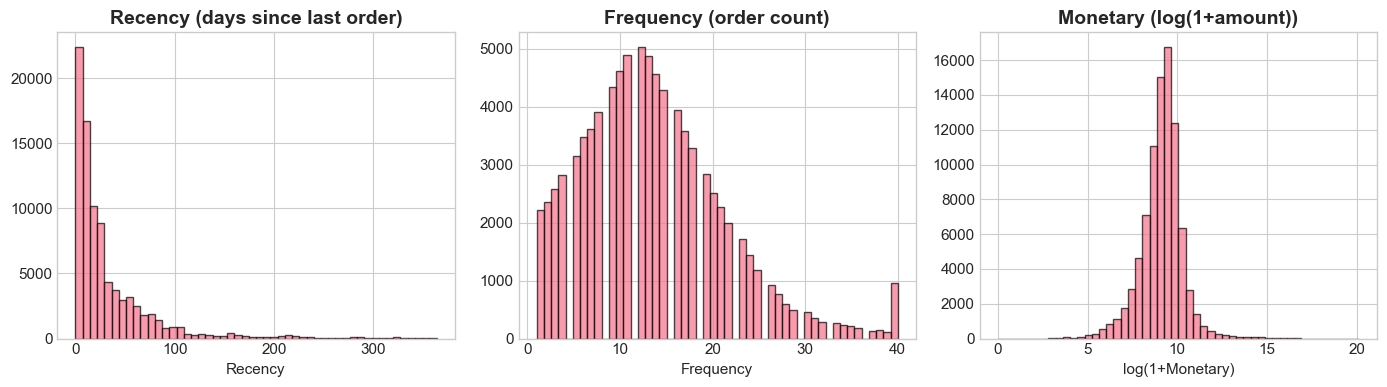

In [8]:
# RFM distributions (histograms)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(df_rfm['Recency'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Recency (days since last order)')
axes[0].set_xlabel('Recency')
axes[1].hist(df_rfm['Frequency'].clip(upper=df_rfm['Frequency'].quantile(0.99)), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Frequency (order count)')
axes[1].set_xlabel('Frequency')
axes[2].hist(np.log1p(df_rfm['Monetary'].dropna()), bins=50, edgecolor='black', alpha=0.7)
axes[2].set_title('Monetary (log(1+amount))')
axes[2].set_xlabel('log(1+Monetary)')
plt.tight_layout()
plt.show()

In [9]:
# Simple RFM segments (quartiles: 1=best, 4=worst for R; 4=best, 1=worst for F and M)
df_rfm['R_quartile'] = pd.qcut(df_rfm['Recency'],                   q=4, labels=[4, 3, 2, 1], duplicates='drop')
df_rfm['F_quartile'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
df_rfm['M_quartile'] = pd.qcut(df_rfm['Monetary'].rank(method='first'),  q=4, labels=[1, 2, 3, 4])
df_rfm['RFM_score']  = df_rfm['R_quartile'].astype(str) + df_rfm['F_quartile'].astype(str) + df_rfm['M_quartile'].astype(str)

# Label segments
def label_segment(row):
    r, f, m = int(row['R_quartile']), int(row['F_quartile']), int(row['M_quartile'])
    if r >= 3 and f >= 3 and m >= 3: return 'Champions'
    if r <= 2 and f <= 2:            return 'Hibernating'
    if r <= 2:                       return 'At risk'
    if f >= 3 and m >= 3:            return 'Loyal'
    return 'Other'
df_rfm['Segment'] = df_rfm.apply(label_segment, axis=1)

# Segment counts
seg_counts = df_rfm['Segment'].value_counts().reset_index()
seg_counts.columns = ['Segment', 'Count']
profile_dataframe('Segment Distribution', seg_counts)

# Mean R/F/M by segment
seg_stats = (
    df_rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']]
    .mean().round(2).reset_index()
)
profile_dataframe('Mean R/F/M by Segment', seg_stats)


In [10]:
# Top customers by Frequency and by Monetary
rfm_cust = df_rfm.merge(
    df_dim_customer[['CustomerKey', 'AccountID', 'AccountName', 'RegionDescription', 'SectorDescription']],
    on='CustomerKey', how='left'
)

cols = ['AccountID', 'AccountName', 'Frequency', 'Monetary', 'Recency']

profile_dataframe('Top 10 Customers by Frequency', rfm_cust.nlargest(10, 'Frequency')[cols].reset_index(drop=True))
profile_dataframe('Top 10 Customers by Monetary',  rfm_cust.nlargest(10, 'Monetary')[cols].reset_index(drop=True))


In [11]:
# Revenue and order count by Region and Sector
sales_by_region = (
    df_fact_sales
    .merge(df_dim_customer[['CustomerKey', 'RegionDescription']], on='CustomerKey')
    .groupby('RegionDescription')
    .agg(revenue=('LineTotalAmount', 'sum'), order_count=('SaleID', 'nunique'))
    .sort_values('revenue', ascending=False)
    .reset_index()
)

sales_by_sector = (
    df_fact_sales
    .merge(df_dim_customer[['CustomerKey', 'SectorDescription']], on='CustomerKey')
    .groupby('SectorDescription')
    .agg(revenue=('LineTotalAmount', 'sum'), order_count=('SaleID', 'nunique'))
    .sort_values('revenue', ascending=False)
    .reset_index()
)

profile_dataframe('Revenue & Orders by Region (top 15)', sales_by_region.head(15))
profile_dataframe('Revenue & Orders by Sector (top 15)', sales_by_sector.head(15))


Column,Type,Nulls,Null %
RegionDescription,str,0,0.0%
revenue,float64,0,0.0%
order_count,int64,0,0.0%
#,RegionDescription,revenue,order_count
0,Central,526954276.07,10934
1,WS ATLANTIC,231050589.25,1753
2,ECOMMERCE,202350710.19,11
3,CASA SUD,114351434.88,38851
4,NORD,88350383.06,245
#,stat,revenue,order_count


Column,Type,Nulls,Null %
SectorDescription,str,0,0.0%
revenue,float64,0,0.0%
order_count,int64,0,0.0%
#,SectorDescription,revenue,order_count
0,Rabat-Salé-WHS-FD,527096771.23,10937
1,ECOMMERCE,202350710.19,11
2,WS CASA SUD - CORPORATE,99653440.65,858
3,WS CASA AS - CORPORATE,86799756.08,548
4,WS MARRAKECH - CORPORATE,66301924.29,806
#,stat,revenue,order_count


In [12]:
# Top products by revenue and quantity
sales_product = df_fact_sales.merge(
    df_dim_product[['ProductKey', 'ItemID', 'ProductName', 'Brand']], on='ProductKey'
)

top_by_revenue = (
    sales_product.groupby(['ItemID', 'ProductName'])
    .agg(revenue=('LineTotalAmount', 'sum'), qty=('Quantity', 'sum'))
    .sort_values('revenue', ascending=False)
    .head(15)
    .reset_index()
)

top_by_qty = (
    sales_product.groupby(['ItemID', 'ProductName'])
    .agg(revenue=('LineTotalAmount', 'sum'), qty=('Quantity', 'sum'))
    .sort_values('qty', ascending=False)
    .head(15)
    .reset_index()
)

profile_dataframe('Top 15 Products by Revenue', top_by_revenue)
profile_dataframe('Top 15 Products by Quantity Sold', top_by_qty)


<a id='5'></a>
## 5. Statistical Summaries and Distributions

Central tendency and spread for RFM and key measures; skewness; time distribution of sales; correlation matrix for R, F, M.

In [13]:
# Numeric summaries and skewness for RFM
from scipy import stats

profile_dataframe('RFM Summary Statistics', df_rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2).reset_index().rename(columns={'index': 'stat'}))

skew_rows = {col: round(stats.skew(df_rfm[col].dropna()), 3) for col in ['Recency', 'Frequency', 'Monetary']}
profile_dataframe('RFM Skewness', pd.DataFrame(list(skew_rows.items()), columns=['Column', 'Skewness']))


In [14]:
# Time distribution: sales by month
df_fact_sales['OrderYearMonth'] = (df_fact_sales['OrderDateKey'] // 100).astype(int)

monthly = (
    df_fact_sales.groupby('OrderYearMonth')
    .agg(
        revenue=('LineTotalAmount', 'sum'),
        order_count=('SaleID', 'nunique'),
        line_count=('SalesKey', 'count')
    )
    .reset_index()
)

profile_dataframe('Sales by Month', monthly)


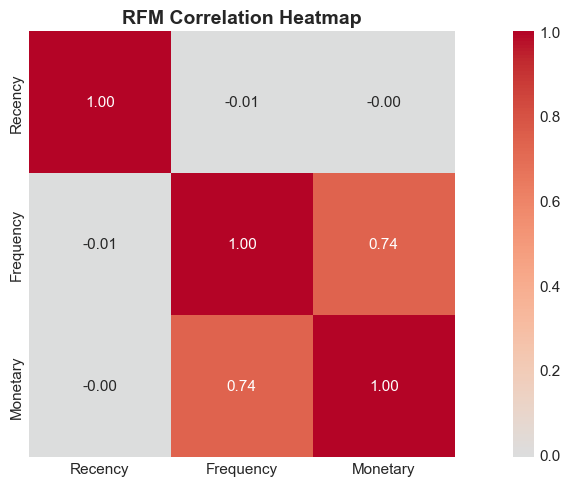

In [15]:
# RFM correlation matrix and heatmap
corr_rfm = df_rfm[['Recency', 'Frequency', 'Monetary']].corr().round(4).reset_index().rename(columns={'index': ''})

profile_dataframe('RFM Correlation Matrix', corr_rfm)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_rfm[['Recency', 'Frequency', 'Monetary']].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('RFM Correlation Heatmap')
plt.tight_layout()
plt.show()


<a id='6'></a>
## 6. Visualizations

Bar charts (revenue/orders by region, sector, promo, payment method), time series (sales by month), box plots (Monetary by segment).

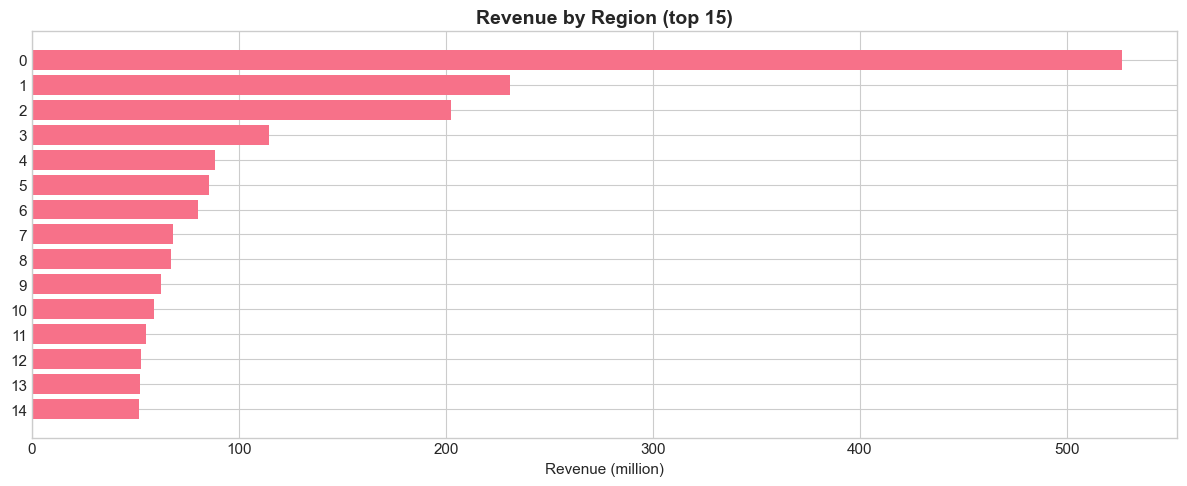

In [16]:
# Bar charts: revenue by region (top 15)
reg = sales_by_region.head(15)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(reg.index.astype(str), reg['revenue'] / 1e6)
ax.set_xlabel('Revenue (million)')
ax.set_title('Revenue by Region (top 15)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

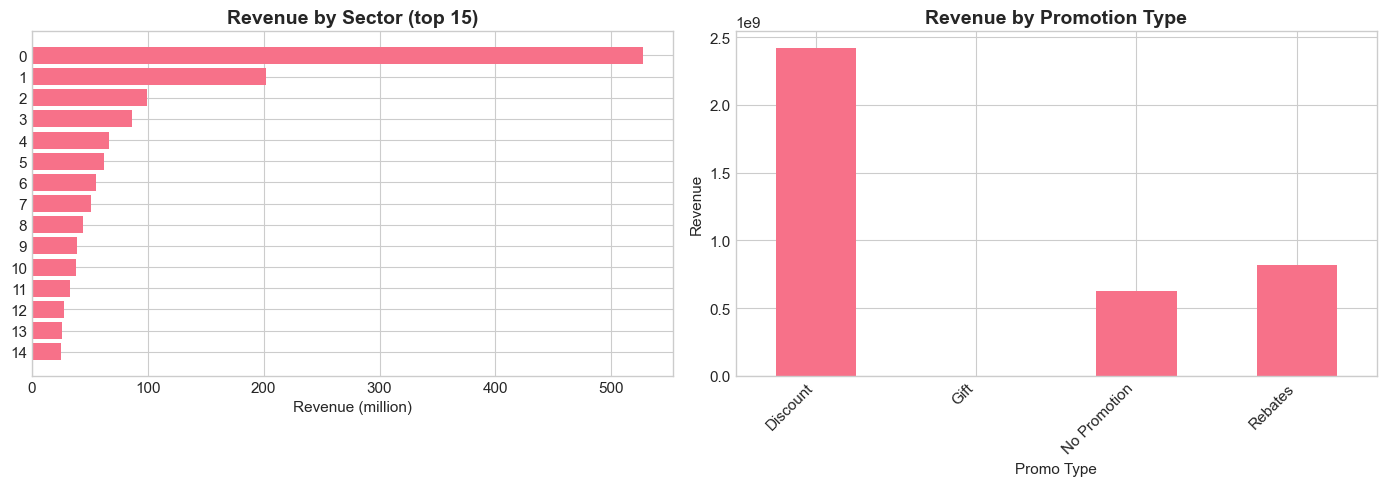

In [17]:
# Bar charts: revenue by sector (top 15) and by promotion type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sec = sales_by_sector.head(15)
axes[0].barh(sec.index.astype(str), sec['revenue'] / 1e6)
axes[0].set_xlabel('Revenue (million)')
axes[0].set_title('Revenue by Sector (top 15)')
axes[0].invert_yaxis()

promo_rev = df_fact_sales.merge(df_dim_promotion[['PromotionKey', 'PromoType']], on='PromotionKey').groupby('PromoType')['LineTotalAmount'].sum()
promo_rev.plot(kind='bar', ax=axes[1])
axes[1].set_xlabel('Promo Type')
axes[1].set_ylabel('Revenue')
axes[1].set_title('Revenue by Promotion Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

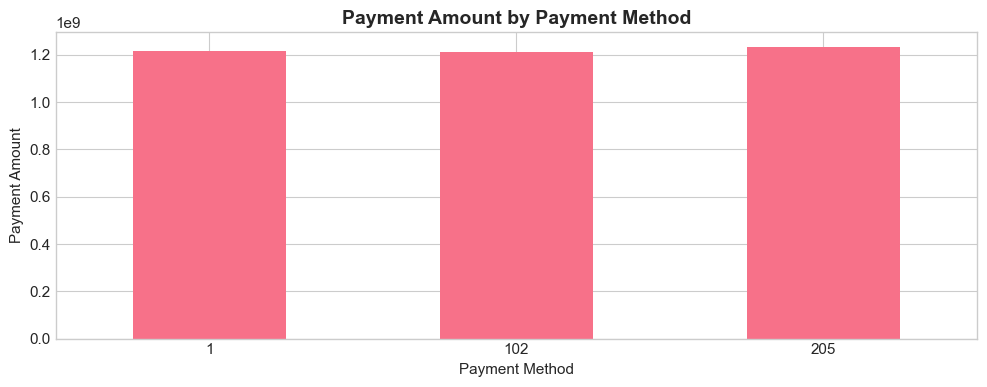

In [18]:
# Revenue by payment method (from FactInvoices)
pay_rev = df_fact_invoices.merge(df_dim_payment[['PaymentMethodKey', 'PaymentMethodCode']], on='PaymentMethodKey').groupby('PaymentMethodCode')['PaymentAmount'].sum()
pay_rev.plot(kind='bar', figsize=(10, 4))
plt.xlabel('Payment Method')
plt.ylabel('Payment Amount')
plt.title('Payment Amount by Payment Method')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

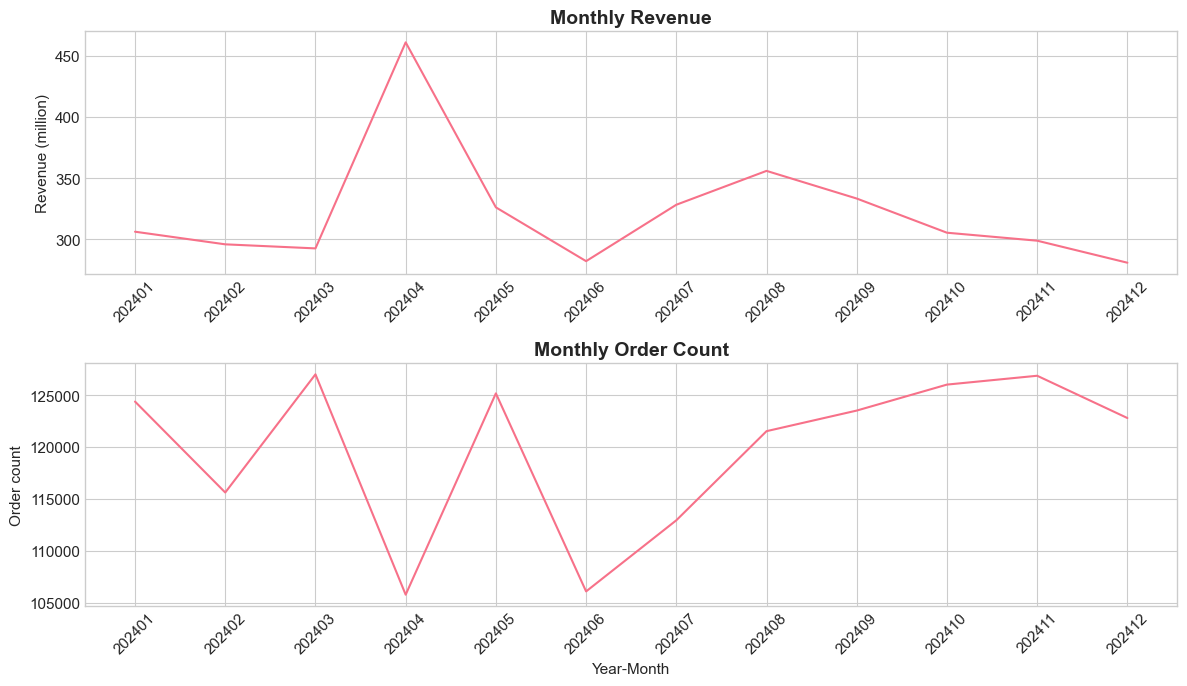

In [19]:
# Time series: revenue and order count by month
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(monthly['OrderYearMonth'].astype(str), monthly['revenue'] / 1e6)
axes[0].set_ylabel('Revenue (million)')
axes[0].set_title('Monthly Revenue')
axes[0].tick_params(axis='x', rotation=45)
axes[1].plot(monthly['OrderYearMonth'].astype(str), monthly['order_count'])
axes[1].set_ylabel('Order count')
axes[1].set_xlabel('Year-Month')
axes[1].set_title('Monthly Order Count')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

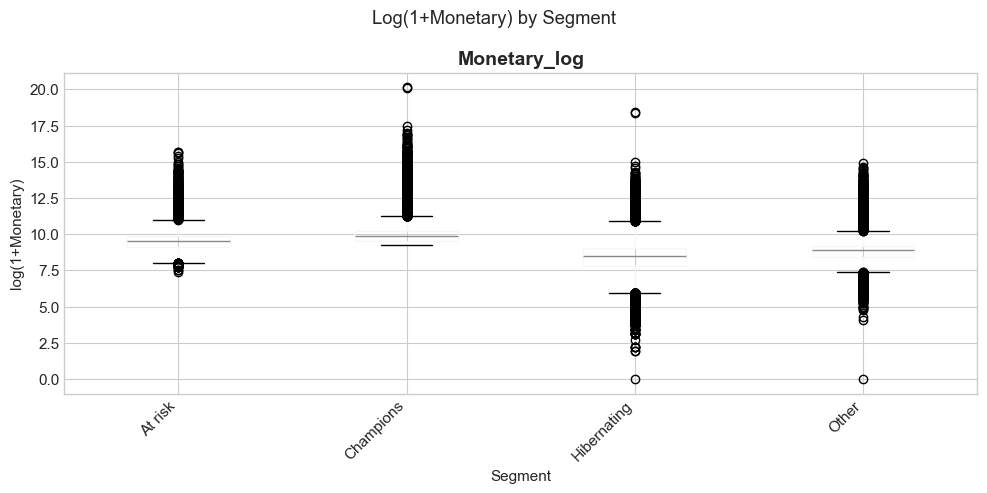

In [20]:
# Box plot: Monetary by RFM Segment
df_rfm['Monetary_log'] = np.log1p(df_rfm['Monetary'])
df_rfm.boxplot(column='Monetary_log', by='Segment', figsize=(10, 5))
plt.suptitle('Log(1+Monetary) by Segment')
plt.xlabel('Segment')
plt.ylabel('log(1+Monetary)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<a id='7'></a>
## 7. Conclusion & Next Steps

**Findings:**
- The data warehouse is fully loaded; all 8 star tables are populated and FKs are consistent.
- RFM distributions show typical patterns: Recency and Frequency are right-skewed; Monetary is highly skewed (log scale helps).
- Segment sizes (Champions, Loyal, At risk, Hibernating) give a first view of customer base health.
- Revenue and orders vary by region, sector, promotion type, and payment method; time series show trends by month.

**Next steps (Phase 3):**
- Use `df_rfm` (and optionally persist it to CSV/Parquet) for **customer segmentation** (e.g. K-Means, DBSCAN) and **churn prediction** (e.g. XGBoost, Random Forest).
- Refine segments and interpret them for business; then move to CLV prediction and dashboards (Phase 4).

In [21]:
# Optional: persist RFM for Phase 3 (segmentation, churn)
# out_dir = PROJECT_ROOT / 'Data' / 'rfm'
# out_dir.mkdir(parents=True, exist_ok=True)
# df_rfm.to_csv(out_dir / 'rfm_customers.csv', index=False)
# print('Saved df_rfm to', out_dir / 'rfm_customers.csv')